In [ ]:
#Число наблюдений n = 80
#Переменные: x - Площадь участка, y - Цена
#Сравниваемые модели: линейная, квадратичная, степенная

In [ ]:
#1) построить диаграмму рассеяния и сформулировать гипотезу о характере связи;
#2) построить линейную и квадратичную модели;
#3) построить дополнительную модель вида y = a x^b;
#4) сравнить модели по R², RMSE, средней ошибке аппроксимации и графикам;
#5) для линейной модели найти остатки, RSS, оценку дисперсии ошибки и доверительные интервалы для коэффициентов;
#6) выполнить прогноз при x*, равном 106% от среднего уровня фактора.

#x* = 5508,1973.

In [ ]:
#Контекст: Цена жилья в зависимости от площади участка.

In [ ]:
#Набор данных
#AER::HousePrices - House Prices in the City of Windsor, Canada
#Страница-источник
#https://vincentarelbundock.github.io/Rdatasets/doc/AER/HousePrices.html
#Как получен срез
#Набор AER::HousePrices; используется равномерная подвыборка по factor lotsize.
#Фактор x
#Площадь участка (lotsize)
#Отклик y
#Цена (price)

Набор данных: AER::HousePrices
Источник: https://vincentarelbundock.github.io/Rdatasets/doc/AER/HousePrices.html
Описание среза: равномерная подвыборка по фактору lotsize из исходного набора.
Число наблюдений: n = 80
x (lotsize): min=1650.0, max=16200.0, среднее=5196.41
y (price):   min=30000.0, max=145000.0, среднее=67792.50


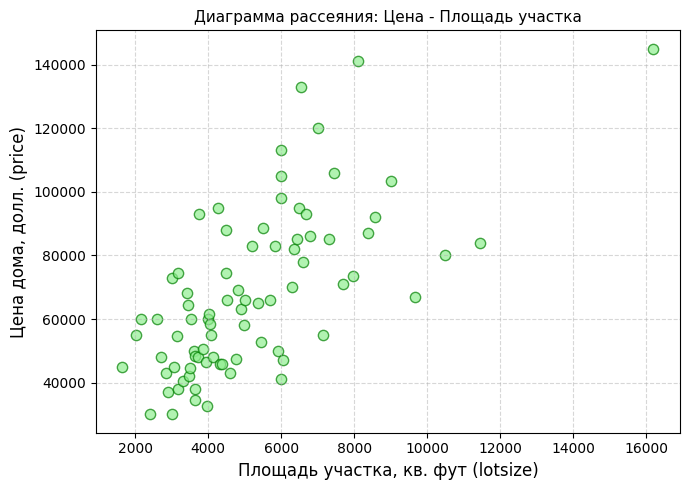

In [ ]:
#4.1
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('RGR3_D_8.csv')
x = df['x'].values
y = df['y'].values
n = len(x)

# 2–3. Информация о наборе данных
print("Набор данных: AER::HousePrices")
print("Источник: https://vincentarelbundock.github.io/Rdatasets/doc/AER/HousePrices.html")
print("Описание среза: равномерная подвыборка по фактору lotsize из исходного набора.")
print(f"Число наблюдений: n = {n}")
print(f"x (lotsize): min={x.min():.1f}, max={x.max():.1f}, среднее={x.mean():.2f}")
print(f"y (price):   min={y.min():.1f}, max={y.max():.1f}, среднее={y.mean():.2f}")
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='lightgreen', edgecolors='green', alpha=0.7, s=55)
plt.xlabel('Площадь участка, кв. фут (lotsize)', fontsize=12)
plt.ylabel('Цена дома, долл. (price)', fontsize=12)
plt.title('Диаграмма рассеяния: Цена - Площадь участка'
         , fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scatter.png', dpi=150)
plt.show()

In [ ]:
print("\nГипотеза о форме и направлении связи:")
print("  По графику наблюдается положительная связь между площадью участка и ценой.")
print("  С ростом x значения y в целом возрастают.")
print("  Разброс точек увеличивается при больших x, что указывает на  возможную нелинейность — подходит степенная или квадратичная модель.")



Гипотеза о форме и направлении связи:
  По графику наблюдается положительная связь между площадью участка и ценой.
  С ростом x значения y в целом возрастают.
  Разброс точек увеличивается при больших x, что указывает на  возможную нелинейность — подходит степенная или квадратичная модель.


Модель 1: Линейная  y = a + b·x
  Параметры:  a = 30837.52,  b = 7.1116
  Уравнение:  y = 30837.52 + 7.1116·x
  Первые 5 прогнозных значений ŷ: [42571.71 45167.46 46091.97 47905.44 49398.88]


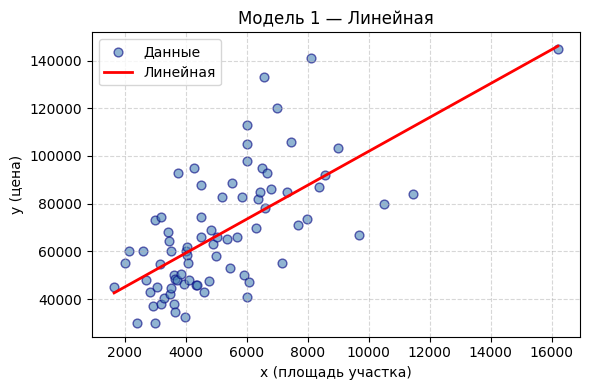

In [ ]:
#4.2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

#Линейная модель
b_l, a_l = np.polyfit(x, y, 1)
y_lin = a_l + b_l * x          # прогнозные значения ŷ

print("Модель 1: Линейная  y = a + b·x")
print(f"  Параметры:  a = {a_l:.2f},  b = {b_l:.4f}")
print(f"  Уравнение:  y = {a_l:.2f} + {b_l:.4f}·x")
print(f"  Первые 5 прогнозных значений ŷ: {y_lin[:5].round(2)}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='steelblue', edgecolors='navy', alpha=0.6, s=40, label='Данные')
xg = np.linspace(x.min(), x.max(), 400)
plt.plot(xg, a_l + b_l * xg, color='red', linewidth=2, label='Линейная')
plt.xlabel('x (площадь участка)')
plt.ylabel('y (цена)')
plt.title('Модель 1 — Линейная')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_linear.png', dpi=150)
plt.show()


 Модель 2: Квадратичная  y = a + b·x + c·x²
  Параметры:  a = 21658.08,  b = 10.2425,  c = -0.000218
  Уравнение:  y = 21658.08 + 10.2425·x + (-0.000218)·x²
  Первые 5 прогнозных значений ŷ: [37964.6  41411.43 42625.03 44984.16 46905.68]


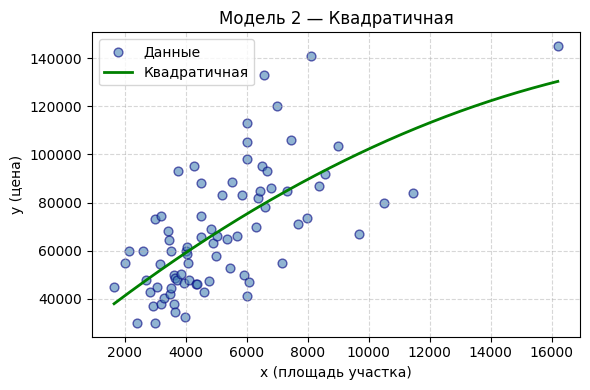

In [ ]:
#Квадратичная модель
c_q, b_q, a_q = np.polyfit(x, y, 2)
y_qua = a_q + b_q * x + c_q * x**2   # прогнозные значения ŷ

print("\n Модель 2: Квадратичная  y = a + b·x + c·x²")
print(f"  Параметры:  a = {a_q:.2f},  b = {b_q:.4f},  c = {c_q:.6f}")
print(f"  Уравнение:  y = {a_q:.2f} + {b_q:.4f}·x + ({c_q:.6f})·x²")
print(f"  Первые 5 прогнозных значений ŷ: {y_qua[:5].round(2)}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='steelblue', edgecolors='navy', alpha=0.6, s=40, label='Данные')
plt.plot(xg, a_q + b_q * xg + c_q * xg**2, color='green', linewidth=2, label='Квадратичная')
plt.xlabel('x (площадь участка)')
plt.ylabel('y (цена)')
plt.title('Модель 2 — Квадратичная')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_quadratic.png', dpi=150)
plt.show()


Модель 3: Степенная  y = a·x^b
  Линеаризация: ln(y) = ln(a) + b·ln(x)
  Параметры:  a = 516.3536,  b = 0.5682
  Уравнение:  y = 516.3536·x^0.5682
  Первые 5 прогнозных значений ŷ: [34771.27 38952.73 40361.44 43021.66 45121.9 ]


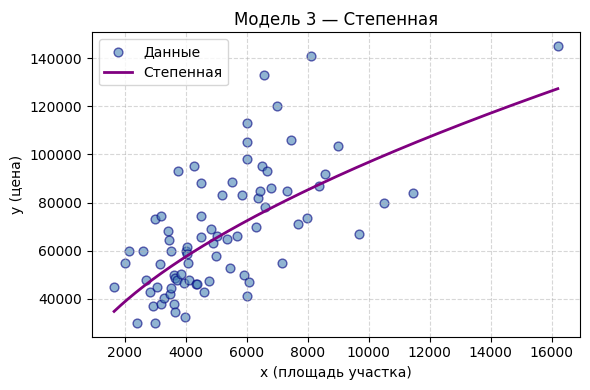

In [ ]:
#Степенная модель
# Линеаризация: ln(y) = ln(a) + b·ln(x)
b_p, ln_a_p, *_ = stats.linregress(np.log(x), np.log(y))
a_p = np.exp(ln_a_p)
y_pow = a_p * x**b_p   # прогнозные значения ŷ

print("\nМодель 3: Степенная  y = a·x^b")
print(f"  Линеаризация: ln(y) = ln(a) + b·ln(x)")
print(f"  Параметры:  a = {a_p:.4f},  b = {b_p:.4f}")
print(f"  Уравнение:  y = {a_p:.4f}·x^{b_p:.4f}")
print(f"  Первые 5 прогнозных значений ŷ: {y_pow[:5].round(2)}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='steelblue', edgecolors='navy', alpha=0.6, s=40, label='Данные')
plt.plot(xg, a_p * xg**b_p, color='purple', linewidth=2, label='Степенная')
plt.xlabel('x (площадь участка)')
plt.ylabel('y (цена)')
plt.title('Модель 3 — Степенная')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_power.png', dpi=150)
plt.show()


Раздел 4.3 — Сравнение моделей

  R²:
    Линейная:      0.4357
    Квадратичная:  0.4445
    Степенная:     0.4331

  Средняя ошибка аппроксимации (MAPE, %):
    Линейная:      24.06%
    Квадратичная:  24.10%
    Степенная:     23.30%


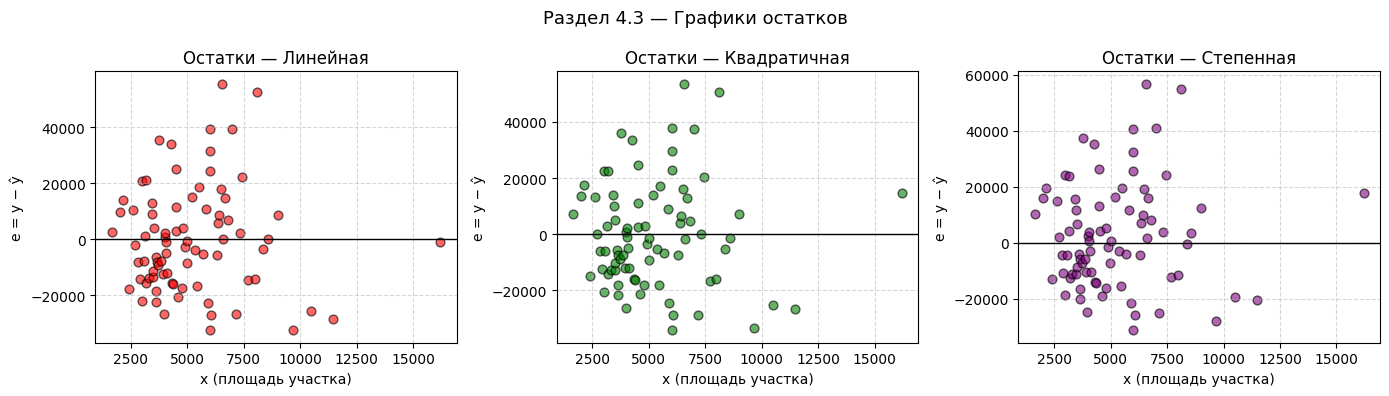

Вывод:
Наибольший R² у модели 'Квадратичная': R² = 0.4445, MAPE = 24.10%
Остатки без тренда, формы моделей адекватно описывают зависимость цены от площади участка —'Квадратичная' модель предпочтительна.


In [ ]:
#4.3
#R² для каждой модели
def R2(y, y_hat):
    return 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)

r2_l = R2(y, y_lin)
r2_q = R2(y, y_qua)
r2_p = R2(y, y_pow)

print("\nРаздел 4.3 — Сравнение моделей")
print(f"\n  R²:")
print(f"    Линейная:      {r2_l:.4f}")
print(f"    Квадратичная:  {r2_q:.4f}")
print(f"    Степенная:     {r2_p:.4f}")

#Средняя ошибка аппроксимации (MAPE)
def MAPE(y, y_hat):
    return np.mean(np.abs((y - y_hat) / y)) * 100

mape_l = MAPE(y, y_lin)
mape_q = MAPE(y, y_qua)
mape_p = MAPE(y, y_pow)

print(f"\n  Средняя ошибка аппроксимации (MAPE, %):")
print(f"    Линейная:      {mape_l:.2f}%")
print(f"    Квадратичная:  {mape_q:.2f}%")
print(f"    Степенная:     {mape_p:.2f}%")

#Графики остатков
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, title, y_hat, color in zip(
    axes,
    ['Линейная', 'Квадратичная', 'Степенная'],
    [y_lin, y_qua, y_pow],
    ['red', 'green', 'purple']
):
    e = y - y_hat
    ax.scatter(x, e, color=color, alpha=0.6, s=40, edgecolors='black')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Остатки — {title}')
    ax.set_xlabel('x (площадь участка)')
    ax.set_ylabel('e = y − ŷ')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Раздел 4.3 — Графики остатков', fontsize=13)
plt.tight_layout()
plt.savefig('residuals.png', dpi=150)
plt.show()


#Вывод
print("Вывод:")
best = max([('Линейная', r2_l, mape_l),
            ('Квадратичная', r2_q, mape_q),
            ('Степенная', r2_p, mape_p)],
           key=lambda t: t[1])
print(f"Наибольший R² у модели '{best[0]}': R² = {best[1]:.4f}, MAPE = {best[2]:.2f}%")
print(f"Остатки без тренда, формы моделей адекватно описывают зависимость цены от площади участка —'{best[0]}' модель предпочтительна.")


In [ ]:
#4.4
#Оценки коэффициентов â и b̂
print(f"\nШаг 1. Оценки коэффициентов:")
print(f"    â = {a_l:.4f}")
print(f"    b̂ = {b_l:.6f}")


#Прогнозные значения ŷ и остатки e
e = y - y_lin

print(f"\nШаг 2. Прогнозные значения ŷ и остатки e (первые 5):")
print(f"    {'i':>4}  {'y':>10}  {'ŷ':>10}  {'e':>10}")
for i in range(5):
    print(f"    {i+1:>4}  {y[i]:>10.2f}  {y_lin[i]:>10.2f}  {e[i]:>10.2f}")


#Остаточная сумма квадратов RSS
RSS = np.sum(e**2)

print(f"\nШаг 3. Остаточная сумма квадратов:")
print(f"    RSS = Σeᵢ² = {RSS:.2f}")


#Оценка дисперсии ошибки s² и s
s2 = RSS / (n - 2)
s  = np.sqrt(s2)

print(f"\nШаг 4. Оценка дисперсии ошибки:")
print(f"    s² = RSS / (n−2) = {RSS:.2f} / {n-2} = {s2:.2f}")
print(f"    s  = √s² = {s:.4f}")


#95% доверительные интервалы для â и b̂
Sxx   = np.sum((x - x.mean())**2)
se_b  = s / np.sqrt(Sxx)
se_a  = s * np.sqrt(1/n + x.mean()**2 / Sxx)
t_cr  = stats.t.ppf(0.975, df=n-2)

ci_b = (b_l - t_cr * se_b, b_l + t_cr * se_b)
ci_a = (a_l - t_cr * se_a, a_l + t_cr * se_a)

print(f"\nШаг 5. Доверительные интервалы (α=0.05, t_кр={t_cr:.4f}):")
print(f"    se(b̂) = {se_b:.6f}")
print(f"    se(â) = {se_a:.4f}")
print(f"    b̂: [{ci_b[0]:.6f};  {ci_b[1]:.6f}]")
print(f"    â: [{ci_a[0]:.4f};  {ci_a[1]:.4f}]")


#Проверка гипотезы H0: b=0
t_obs = b_l / se_b

print(f"\nШаг 6. Проверка гипотезы H₀: b=0, H₁: b≠0 (α=0.05):")
print(f"    t_набл = b̂ / se(b̂) = {b_l:.6f} / {se_b:.6f} = {t_obs:.4f}")
print(f"    t_кр   = {t_cr:.4f}  (df={n-2})")
print(f"    |t_набл| = {abs(t_obs):.4f}  {'>' if abs(t_obs) > t_cr else '<'}  t_кр = {t_cr:.4f}")


#Вывод о значимости
print(f"\nШаг 7. Вывод:")
if abs(t_obs) > t_cr:
    print(f"|t_набл| > t_кр → H₀ отвергается.")
    print(f"Коэффициент b статистически значим на уровне α=0.05.")
    print(f"Площадь участка значимо влияет на цену.")
else:
    print(f"|t_набл| < t_кр → H₀ не отвергается.")
    print(f"Коэффициент b статистически незначим на уровне α=0.05.")


Шаг 1. Оценки коэффициентов:
    â = 30837.5170
    b̂ = 7.111634

Шаг 2. Прогнозные значения ŷ и остатки e (первые 5):
       i           y           ŷ           e
       1    45000.00    42571.71     2428.29
       2    55000.00    45167.46     9832.54
       3    60000.00    46091.97    13908.03
       4    30000.00    47905.44   -17905.44
       5    60000.00    49398.88    10601.12

Шаг 3. Остаточная сумма квадратов:
    RSS = Σeᵢ² = 28887603830.90

Шаг 4. Оценка дисперсии ошибки:
    s² = RSS / (n−2) = 28887603830.90 / 78 = 370353895.27
    s  = √s² = 19244.5809

Шаг 5. Доверительные интервалы (α=0.05, t_кр=1.9908):
    se(b̂) = 0.916398
    se(â) = 5225.5033
    b̂: [5.287226;  8.936042]
    â: [20434.3392;  41240.6949]

Шаг 6. Проверка гипотезы H₀: b=0, H₁: b≠0 (α=0.05):
    t_набл = b̂ / se(b̂) = 7.111634 / 0.916398 = 7.7604
    t_кр   = 1.9908  (df=78)
    |t_набл| = 7.7604  >  t_кр = 1.9908

Шаг 7. Вывод:
|t_набл| > t_кр → H₀ отвергается.
Коэффициент b статистически значим 

In [ ]:
x_star = 5508.1973

#Прогноз по каждой модели
yhat_lin = a_l + b_l * x_star
yhat_qua = a_q + b_q * x_star + c_q * x_star**2
yhat_pow = a_p * x_star**b_p

print("Раздел 4.5 — Прогноз при x* = 5508.1973")
print(f"\n  Шаг 1. Прогнозные значения ŷ(x*):")
print(f"    Линейная:      ŷ = {yhat_lin:.2f} долл.")
print(f"    Квадратичная:  ŷ = {yhat_qua:.2f} долл.")
print(f"    Степенная:     ŷ = {yhat_pow:.2f} долл.")

#Выбор основной модели
print(f"\n  Шаг 2. Выбор основной модели (по R²):")
print(f"    R² линейная:      {r2_l:.4f}")
print(f"    R² квадратичная:  {r2_q:.4f}")
print(f"    R² степенная:     {r2_p:.4f}")


Раздел 4.5 — Прогноз при x* = 5508.1973

  Шаг 1. Прогнозные значения ŷ(x*):
    Линейная:      ŷ = 70009.80 долл.
    Квадратичная:  ŷ = 71460.24 долл.
    Степенная:     ŷ = 68976.92 долл.

  Шаг 2. Выбор основной модели (по R²):
    R² линейная:      0.4357
    R² квадратичная:  0.4445
    R² степенная:     0.4331


In [ ]:
print(f"""
    Все три модели дают близкие значения R² (0.43–0.44),
    квадратичная незначительно лучше (R²=0.4445).
    Однако коэффициент c при x² мал, а содержательный
    смысл квадратичной кривой здесь не очевиден.
    Линейная модель проще, её коэффициент b статистически
    значим (t=7.76 >> t_кр=1.99), поэтому выбираем её как основную
""")

# Интерпретация
print(f"Шаг 3. Интерпретация:")
print(f"""
    x* = {x_star} кв. фут — это 106% от среднего по выборке
    (x̄ = {x.mean():.2f} кв. фут), то есть участок чуть больше среднего.

    Прогноз по линейной модели: ŷ = {yhat_lin:.0f} долл.
    Это близко к среднему уровню цен по выборке (ȳ = 67792.50 долл.),
    что логично: x* лишь на 6% выше среднего.

    Все три модели дают схожий результат (69–71 тыс. долл.),
    что подтверждает устойчивость прогноза.
""")


    Все три модели дают близкие значения R² (0.43–0.44),
    квадратичная незначительно лучше (R²=0.4445).
    Однако коэффициент c при x² мал, а содержательный
    смысл квадратичной кривой здесь не очевиден.
    Линейная модель проще, её коэффициент b статистически
    значим (t=7.76 >> t_кр=1.99), поэтому выбираем её как основную

Шаг 3. Интерпретация:

    x* = 5508.1973 кв. фут — это 106% от среднего по выборке
    (x̄ = 5196.41 кв. фут), то есть участок чуть больше среднего.

    Прогноз по линейной модели: ŷ = 70010 долл.
    Это близко к среднему уровню цен по выборке (ȳ = 67792.50 долл.),
    что логично: x* лишь на 6% выше среднего.

    Все три модели дают схожий результат (69–71 тыс. долл.),
    что подтверждает устойчивость прогноза.



In [ ]:
print("Итоговый вывод:")
print(f"""
    Изучалась зависимость цены дома (y, долл.) от площади
    участка (x, кв. фут).
    Диаграмма рассеяния показала
    положительную связь: при росте площади от 1650 до 16200 кв. фут
    цена возрастает от 30000 до 145000 долл.

    Были построены три модели: линейная (R²=0.4357),
    квадратичная (R²=0.4445) и степенная (R²=0.4331).
    Все модели объясняют около 43–44% разброса цен —
    умеренное качество, что типично для одного фактора:
    на цену влияют также число комнат, этаж, район и др.

    Предпочтительна линейная модель:
    ŷ = 30837.52 + 7.11·x.
    Коэффициент b=7.11 значим (t=7.76 > t_кр=1.99):
    каждый дополнительный квадратный фут площади участка
    в среднем увеличивает цену дома на 7.11 долл.

    При x*=5508.20 кв. фут прогнозная цена составляет
    около 70010 долл. — чуть выше среднего по выборке (67793 долл.),
    что соответствует незначительному превышению x* над x̄.
""")

Итоговый вывод:

    Изучалась зависимость цены дома (y, долл.) от площади
    участка (x, кв. фут).
    Диаграмма рассеяния показала
    положительную связь: при росте площади от 1650 до 16200 кв. фут
    цена возрастает от 30000 до 145000 долл.

    Были построены три модели: линейная (R²=0.4357),
    квадратичная (R²=0.4445) и степенная (R²=0.4331).
    Все модели объясняют около 43–44% разброса цен —
    умеренное качество, что типично для одного фактора:
    на цену влияют также число комнат, этаж, район и др.

    Предпочтительна линейная модель:
    ŷ = 30837.52 + 7.11·x.
    Коэффициент b=7.11 значим (t=7.76 > t_кр=1.99):
    каждый дополнительный квадратный фут площади участка
    в среднем увеличивает цену дома на 7.11 долл.

    При x*=5508.20 кв. фут прогнозная цена составляет
    около 70010 долл. — чуть выше среднего по выборке (67793 долл.),
    что соответствует незначительному превышению x* над x̄.

